In [544]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
## opens sqlite database

conn = sqlite3.connect("./data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [545]:
def ships_over_frame(max_frames = 999999999):
  result = statement_to_df(f"""
    with combined as (select * from (select frame, 1 as val, owner from ships_created
    union all 
    select frame, -1 as val, owner from ships_destroyed)
    order by frame
  ),
  grouped as (select x, sum(y) over (order by x) as y from (select frame as x, sum(val) as y from combined group by frame))
  select * from grouped where x <= {max_frames} order by x;
  """)
  return result

def ships_grouped_over_frame(max_frames = 999999999):
  result = statement_to_df(f"""
    with combined as (select * from (select frame, 1 as val, owner from ships_created
    union all 
    select frame, -1 as val, owner from ships_destroyed)
    order by frame
  ),
  partitioned as (select owner, x, sum(y) over (partition by owner order by x) as y 
  from (select owner, frame as x, sum(val) as y from combined group by frame, owner)
  )

  select * from partitioned where x <= {max_frames} order by owner, x;
                           
""")
  return result




In [546]:
get_tables()

['ships_destroyed',
 'ships_created',
 'players',
 'servers',
 'server_ticks',
 'pings',
 'player_counts']

In [547]:
def plot_all(max_frames = 999999999):
    fig, axes = plt.subplots(4, 1, figsize=(16,12), dpi=160, sharex = True)
    ticks = statement_to_df(f"select tick as x, micros_elapsed / 1000.0 as y, game_id from server_ticks where tick <= {max_frames}")
    grouped_ticks = ticks.groupby("game_id")
    for name, group in grouped_ticks:
        axes[0].plot(group["x"], group["y"], label=name)
        axes[0].set_title("Server time to calculate tick")
        axes[0].set_ylabel("Server Tick (ms)")

    pings = statement_to_df(f"select tick as x, micros / 1000.0 as y from pings where tick <= {max_frames}")
    # ping_moving_avg = pings["y"].rolling(window=5).mean()
    axes[1].plot(pings["x"], pings["y"])
    axes[1].set_title("Client ping over time")
    axes[1].set_ylabel("Ping (ms)")

    ships = ships_over_frame(max_frames)
    axes[2].plot(ships["x"], ships["y"], label="Total Ships")
    axes[2].set_title("Total ships over time")
    axes[2].set_ylabel("Ships")

    for name, group in ships_grouped_over_frame(max_frames).groupby(["owner"]):
        #extend line to the end
        if len(group["x"]) > 1:
            axes[3].plot(group["x"], group["y"], label=name)
        else:
            axes[3].scatter(group["x"], group["y"], label=name)

    total_seconds = ticks["x"].max()*1/60
    axes[3].set_title("Ships per player over time")
    axes[3].set_xlabel(f"Frame ({total_seconds.round()} seconds)")
    #axes[3].legend()
    return [ticks, pings, ships]
# player_counts = statement_to_df("select tick as x, count as y from player_counts")


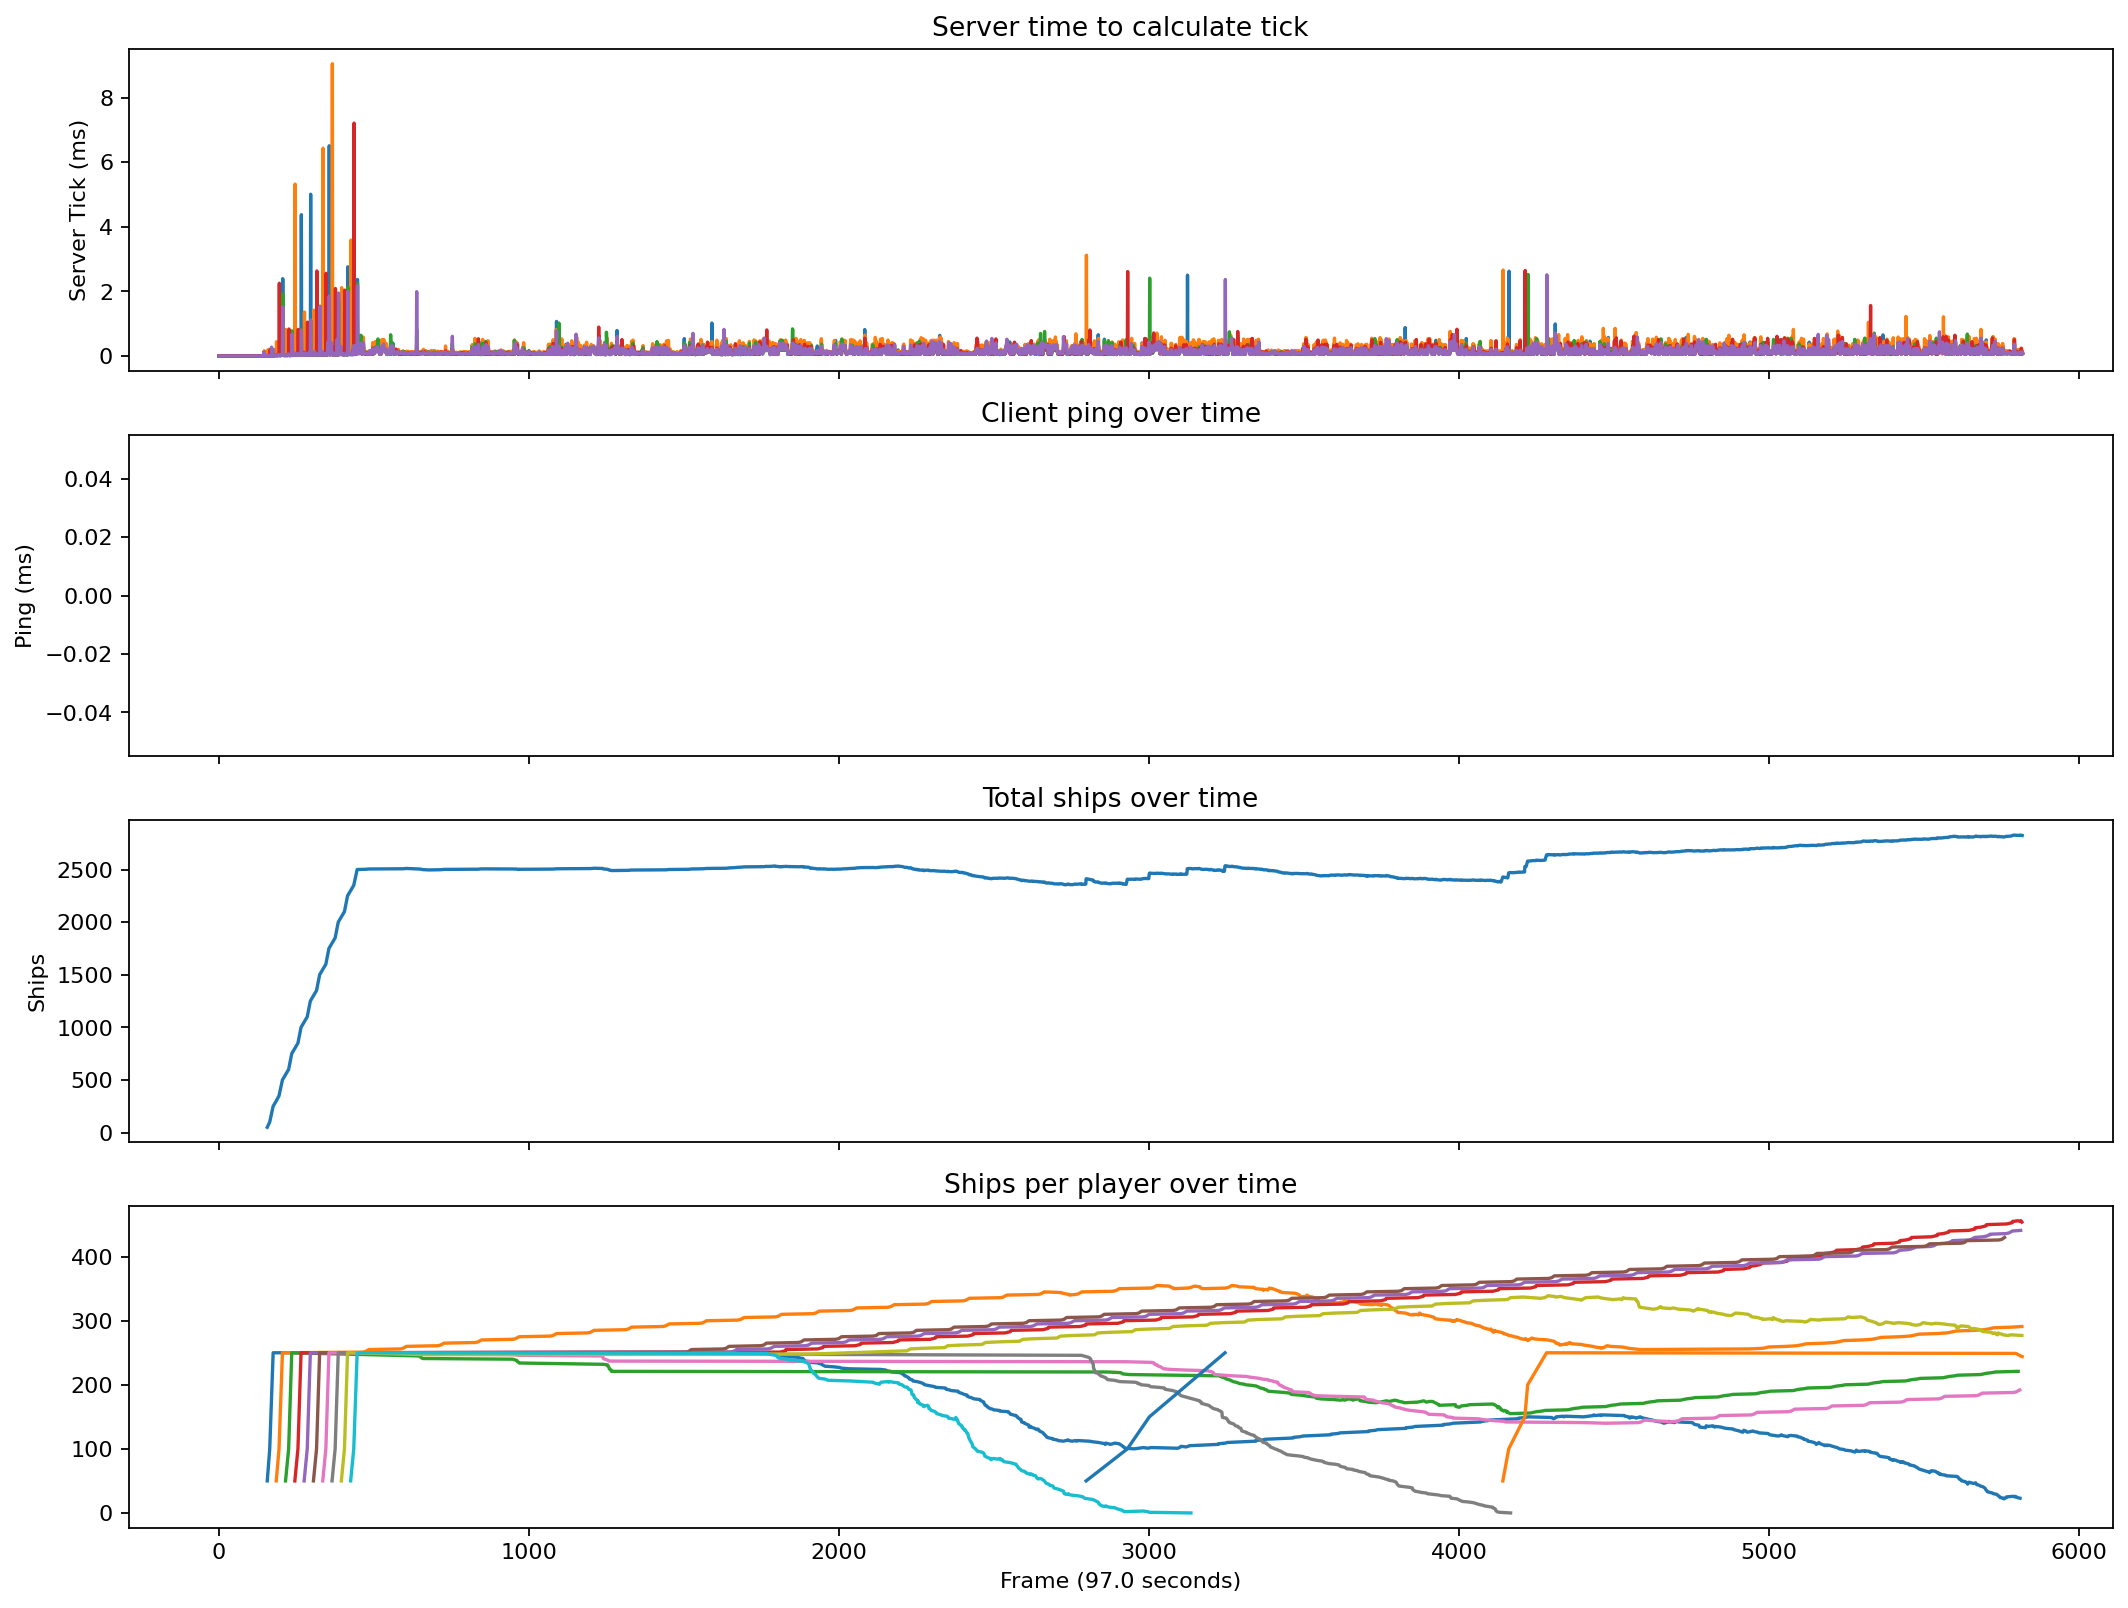

In [552]:
[ticks, pings, ships] = plot_all()

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

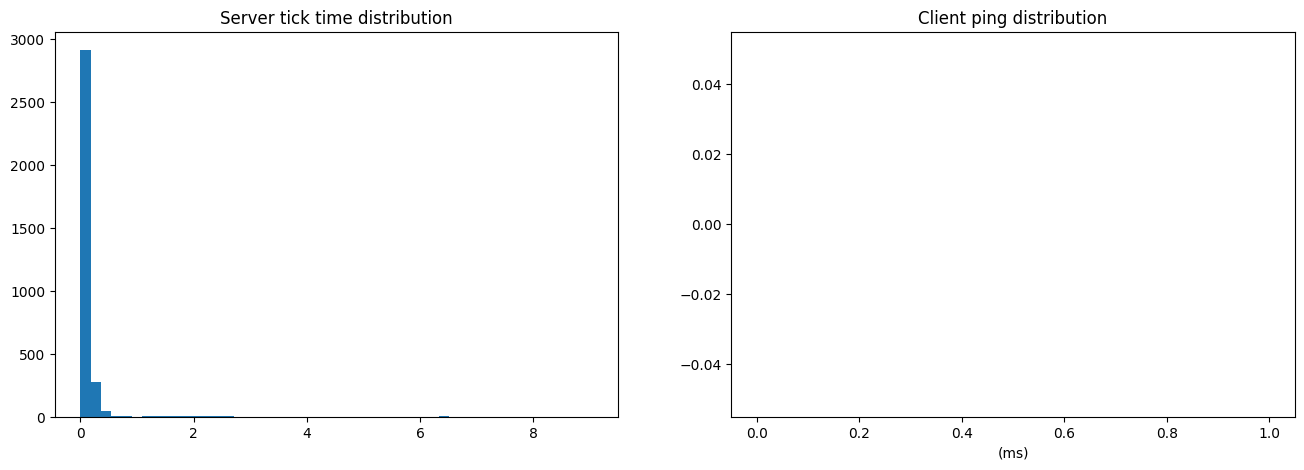

In [549]:
fig, axes = plt.subplots(1,2, figsize=(16, 5))
axes[0].set_title("Server tick time distribution")
axes[0].hist(ticks["y"], bins=50)
axes[1].set_xlabel("(ms)")
axes[1].set_title("Client ping distribution")
axes[1].set_xlabel("(ms)")
axes[1].hist(pings["y"], bins=50)

In [550]:
df = statement_to_df(f"select tick as x, micros_elapsed / 1000.0 as y, game_id from server_ticks")
df.groupby("game_id").count()

,x,y
game_id,,
1,718,718
2,718,718
3,718,718
4,718,718
5,718,718
